Cor principal: 186,139,157

Cor da borda: 255,161,247

In [1]:
!pip install plotly
!pip install matplotlib
!pip install scikit-learn
!pip install tqdm


[notice] A new release of pip available: 22.3 -> 23.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip available: 22.3 -> 23.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 23.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 23.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Ler a imagem e mostrar na tela

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Carregar a imagem
image_path = '0614.tif'
image_path = 'polem4Pares.jpg'
image = Image.open(image_path)

# Converter a imagem em um vetor NumPy 3D
image_array = np.array(image)

print(image_array)

[[[175 181 171]
  [182 188 176]
  [188 194 182]
  ...
  [216 220 221]
  [218 222 223]
  [219 223 224]]

 [[176 182 172]
  [182 188 176]
  [187 193 181]
  ...
  [216 220 221]
  [216 220 221]
  [216 220 221]]

 [[177 183 173]
  [182 188 176]
  [186 192 180]
  ...
  [215 219 220]
  [215 219 220]
  [214 218 219]]

 ...

 [[253 251 254]
  [251 251 251]
  [250 250 250]
  ...
  [252 251 247]
  [252 251 247]
  [252 251 247]]

 [[254 252 255]
  [255 253 255]
  [255 254 255]
  ...
  [255 253 254]
  [255 254 252]
  [255 253 254]]

 [[251 246 253]
  [250 248 253]
  [253 251 254]
  ...
  [253 251 254]
  [253 251 252]
  [252 250 253]]]


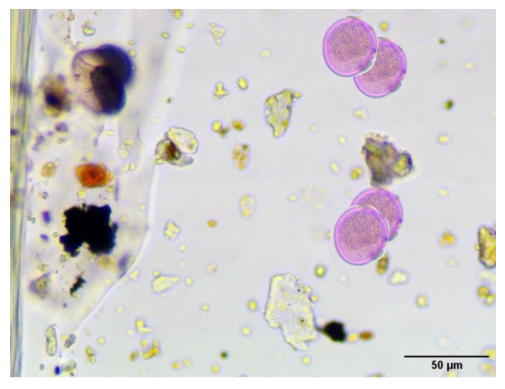

In [3]:
import plotly.graph_objects as go

# Exibir a imagem com matplotlib
plt.imshow(image_array)
plt.axis('off')  # Desativar os eixos
plt.show()

# Analisando

Para poder analisar apenas a região do pólem, vamos aplicar um filtro para apenas analisar os pontos com os tons da região desejada (rosa). Assim será criada uma máscara

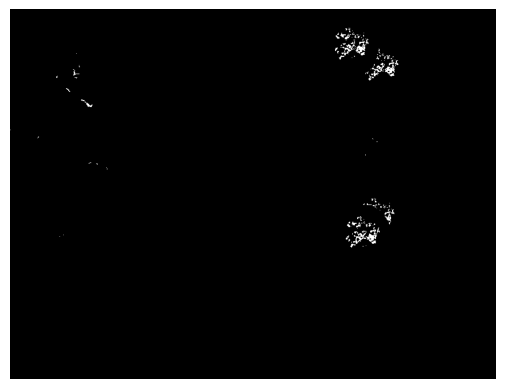

In [4]:
# Definir a cor de referência
reference_color = np.array([186, 139, 157])

# Calcular a distância euclidiana para cada ponto da imagem
distances_center = np.linalg.norm(image_array - reference_color, axis=2)

# Criar um vetor binário baseado na distância euclidiana
binary_array_center = distances_center < 15   # Altere esse valor para ver o resultado

# Exibir o vetor binário
plt.imshow(binary_array_center, cmap='gray')
plt.axis('off')
plt.show()

Há conjuntos dispersos, mas a maior concentração está sobre a região desejada

## Agora analisando com a cor da borda

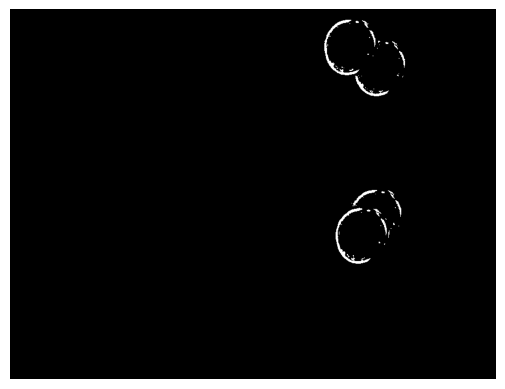

In [5]:
# Definir a cor de referência
reference_color = np.array([255,161,247])

# Calcular a distância euclidiana para cada ponto da imagem
distances_edge = np.linalg.norm(image_array - reference_color, axis=2)

# Criar um vetor binário baseado na distância euclidiana
binary_array_edge = distances_edge < 50   # Altere esse valor para ver o resultado

# Exibir o vetor binário
plt.imshow(binary_array_edge, cmap='gray')
plt.axis('off')
plt.show()

O resultado concentra todos os pontos na borda desejada, mas ela não está completa

## Aqui é usado HSL para definir o que é rosa

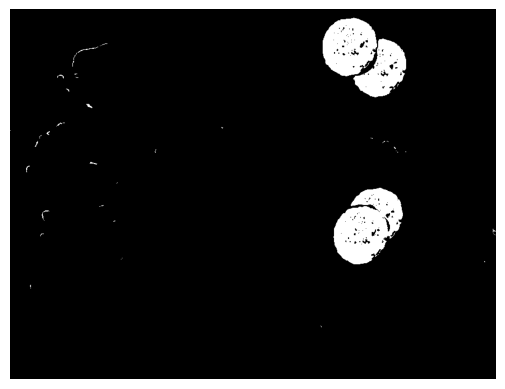

In [6]:
import colorsys

binary_array_hsl = np.full(image_array.shape[:-1], False)

for i in range(image_array.shape[0]):
    for j in range(image_array.shape[1]):
        h,l,s = colorsys.rgb_to_hls(image_array[i][j][0]+0.0001, image_array[i][j][1]+0.0001, image_array[i][j][2]+0.0001)
        # print(h,s,l)
        if  0.94 > h > 0.75 and s < -0.1 and l> 150:
            binary_array_hsl[i][j] = True

# Exibir o vetor binário
plt.imshow(binary_array_hsl, cmap='gray')
plt.axis('off')
plt.show()


# Contando os grupos com DBSCAN

Através desse algoritmo, é possível definir quantos pontos cada ponto do conjunto deve possuir em sua região para ser considerado e tembém o tamanho da região

## Para o conjunto interno:

In [7]:
from sklearn.cluster import DBSCAN

# Suponha que o vetor binário esteja calculado e armazenado em binary_array

# Obter as coordenadas dos pontos brancos (True) no vetor binário
white_points = np.argwhere(binary_array_center)

# Executar o algoritmo DBSCAN
epsilon = 20  # Raio da vizinhança # Altere esse valor para ver o resultado
min_samples = 80  # Número mínimo de amostras para formar um cluster # Altere esse valor para ver o resultado
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
labels = dbscan.fit_predict(white_points)

print(f"O número de manchas encontradas foi de {labels.max()+1}")

O número de manchas encontradas foi de 4


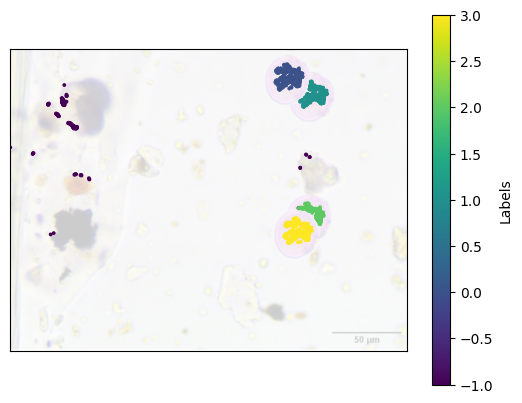

In [8]:
# Criar a figura do Matplotlib
fig, ax = plt.subplots()

# Adicionar a imagem original ao plot
ax.imshow(image_array, alpha=0.2)

# Adicionar os pontos do DBSCAN ao plot
scatter = ax.scatter(
    white_points[:, 1],
    white_points[:, 0],
    c=labels,
    cmap='viridis',
    s=3
)

# Configurar o layout
ax.set_xticks([])
ax.set_yticks([])
ax.margins(0.05, 0.05)

# Criar uma barra de cores
cbar = plt.colorbar(scatter)
cbar.set_label('Labels')

# Exibir o plot
plt.show()


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from matplotlib.lines import Line2D

# Suponha que o vetor binário esteja calculado e armazenado em binary_array

# Obter as coordenadas dos pontos brancos (True) no vetor binário
white_points = np.argwhere(binary_array_edge)

# Executar o algoritmo DBSCAN 
epsilon = 40  # Raio da vizinhança # Altere esse valor para ver o resultado
min_samples = 20  # Número mínimo de amostras para formar um cluster # Altere esse valor para ver o resultado
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
labels = dbscan.fit_predict(white_points)

print(f"O número de manchas encontradas foi de {labels.max()+1}")

O número de manchas encontradas foi de 2


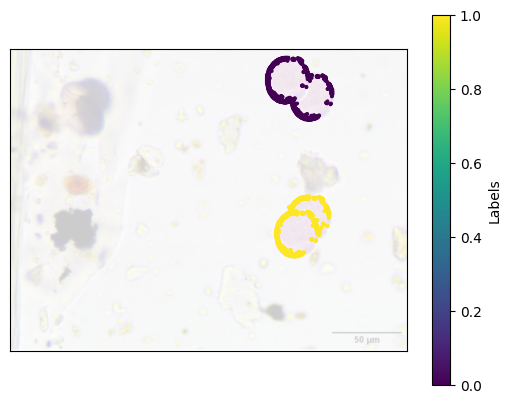

In [10]:
# Converter a imagem em um vetor NumPy 3D com opacidade de 20%
image_array_with_opacity = np.concatenate([image_array, np.full_like(image_array[..., :1], 51)], axis=2)

# Criar a figura do Matplotlib
fig, ax = plt.subplots()

# Adicionar a imagem original ao plot com opacidade de 20%
ax.imshow(image_array_with_opacity)

# Adicionar os pontos do DBSCAN ao plot
scatter = ax.scatter(
    white_points[:, 1],
    white_points[:, 0],
    c=labels,
    cmap='viridis',
    s=3
)

# Configurar o layout
ax.set_xticks([])
ax.set_yticks([])
ax.margins(0.05, 0.05)

# Criar uma barra de cores
cbar = plt.colorbar(scatter)
cbar.set_label('Labels')

# Exibir o plot
plt.show()


In [71]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from matplotlib.lines import Line2D

# Suponha que o vetor binário esteja calculado e armazenado em binary_array

# Obter as coordenadas dos pontos brancos (True) no vetor binário
white_points = np.argwhere(binary_array_hsl)

# Executar o algoritmo DBSCAN 
epsilon = 10  # Raio da vizinhança # Altere esse valor para ver o resultado
min_samples = 100  # Número mínimo de amostras para formar um cluster # Altere esse valor para ver o resultado
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
labels = dbscan.fit_predict(white_points)

print(f"O número de manchas encontradas foi de {labels.max()+1}")

O número de manchas encontradas foi de 2


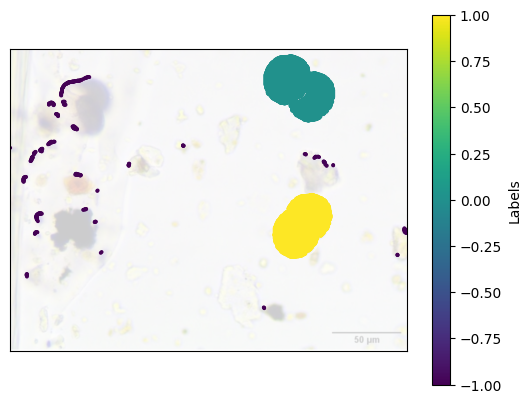

In [64]:
# Converter a imagem em um vetor NumPy 3D com opacidade de 20%
image_array_with_opacity = np.concatenate([image_array, np.full_like(image_array[..., :1], 51)], axis=2)

# Criar a figura do Matplotlib
fig, ax = plt.subplots()

# Adicionar a imagem original ao plot com opacidade de 20%
ax.imshow(image_array_with_opacity)

# Adicionar os pontos do DBSCAN ao plot
scatter = ax.scatter(
    white_points[:, 1],
    white_points[:, 0],
    c=labels,
    cmap='viridis',
    s=3
)

# Configurar o layout
ax.set_xticks([])
ax.set_yticks([])
ax.margins(0.05, 0.05)

# Criar uma barra de cores
cbar = plt.colorbar(scatter)
cbar.set_label('Labels')

# Exibir o plot
plt.show()
